In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import math
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

# 1. Problem Formulation
Design a ML model that would predict whether a person has heart disease or not.

# 2. Data collection


In [21]:
# df = pd.read_csv('heart_disease.csv')
df = pd.read_csv('data_heart_v2.csv')
print(df.sample(10))

     age  sex   BP  cholestrol  heart disease
146   52    1  112         230              1
108   59    1  140         177              1
230   61    0  145         307              1
1     67    0  115         564              0
207   58    1  105         240              0
19    40    1  140         199              0
93    54    1  110         206              1
238   47    1  138         257              0
29    71    0  110         265              0
63    60    0  150         240              0


# 3. Fix Data Types + Data cleaning + Data labelling


In [22]:
# I want to see the descriptive stats of all numerical columns
# Set the option to display all columns
pd.set_option('display.max_columns', None)
print(df.describe())
pd.reset_option('display.max_columns')


              age         sex          BP  cholestrol  heart disease
count  270.000000  270.000000  270.000000  270.000000     270.000000
mean    54.433333    0.677778  131.344444  249.659259       0.444444
std      9.109067    0.468195   17.861608   51.686237       0.497827
min     29.000000    0.000000   94.000000  126.000000       0.000000
25%     48.000000    0.000000  120.000000  213.000000       0.000000
50%     55.000000    1.000000  130.000000  245.000000       0.000000
75%     61.000000    1.000000  140.000000  280.000000       1.000000
max     77.000000    1.000000  200.000000  564.000000       1.000000


In [4]:
print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            270 non-null    int64
 1   sex            270 non-null    int64
 2   BP             270 non-null    int64
 3   cholestrol     270 non-null    int64
 4   heart disease  270 non-null    int64
dtypes: int64(5)
memory usage: 10.7 KB
None


In [5]:
# Lets print memory usage before memory optimization

print(df.memory_usage(deep=True))
print(f"Before optimization: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

Index             132
age              2160
sex              2160
BP               2160
cholestrol       2160
heart disease    2160
dtype: int64
Before optimization: 10.68 KB


In [ ]:
# Lets drop columns that we do not need: "EmployeeCount", "EmployeeNumber", etc and other columns if needed
# df.drop(columns=["EmployeeCount", "EmployeeNumber", "StandardHours"], inplace=True)

# print(df.memory_usage(deep=True))
# print(f"Memory now: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

In [6]:
# Downcast integer int64 columns to int8, int16, int32, int64 based on the data range present
int_cols = df.select_dtypes(include=['int64']).columns
df[int_cols] = df[int_cols].apply(pd.to_numeric, downcast='integer')

print(df.memory_usage(deep=True))
print(f"Memory now: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

Index            132
age              270
sex              270
BP               540
cholestrol       540
heart disease    270
dtype: int64
Memory now: 1.97 KB


In [7]:
print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            270 non-null    int8 
 1   sex            270 non-null    int8 
 2   BP             270 non-null    int16
 3   cholestrol     270 non-null    int16
 4   heart disease  270 non-null    int8 
dtypes: int16(2), int8(3)
memory usage: 2.0 KB
None


In [23]:
df['sex'] = df['sex'].map({0: False, 1: True})

In [24]:
print(df.memory_usage(deep=True))
print(f"Memory now: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(df.info(memory_usage='deep'))

Index             132
age              2160
sex               270
BP               2160
cholestrol       2160
heart disease    2160
dtype: int64
Memory now: 8.83 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            270 non-null    int64
 1   sex            270 non-null    bool 
 2   BP             270 non-null    int64
 3   cholestrol     270 non-null    int64
 4   heart disease  270 non-null    int64
dtypes: bool(1), int64(4)
memory usage: 8.8 KB
None


In [25]:
# # Convert object to Categorical Text Columns

# obj_cols = df.select_dtypes(include=['object']).columns

# for col in obj_cols:
#     num_unique = df[col].nunique()
#     num_total = len(df[col])
#     if num_unique / num_total < 0.5:  # heuristic: if < 50% unique
#         print(f"Converting {col} to datatype category")
#         df[col] = df[col].astype('category')


# print(df.memory_usage(deep=True))
# print(f"Memory now: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

In [28]:
# How much memory saved ? 81%
(10.7 - 2)/10.7

0.8130841121495327

# 4. EDA


In [29]:
# Check for class imbalance
df['heart disease'].value_counts()

heart disease
0    150
1    120
Name: count, dtype: int64

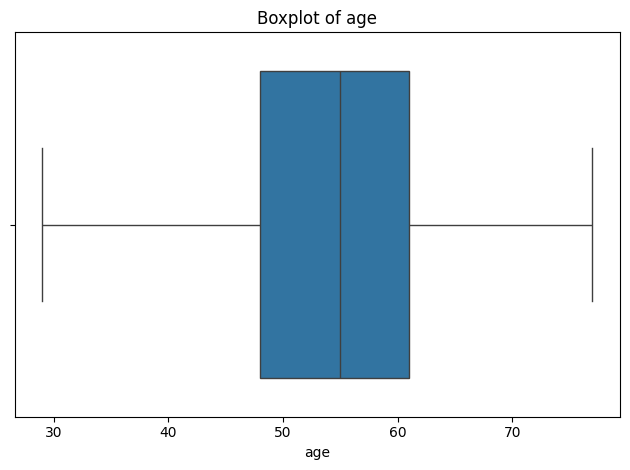

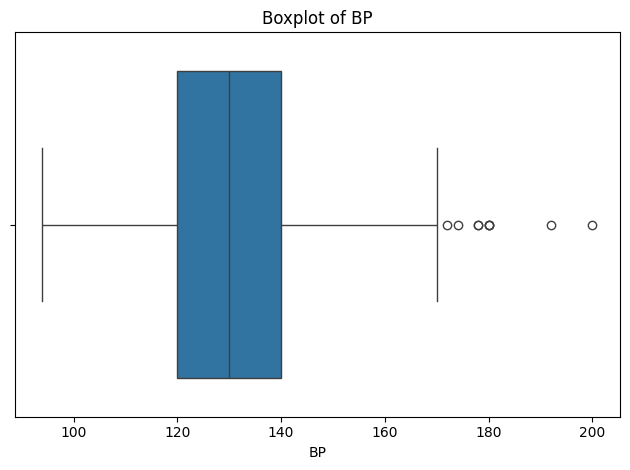

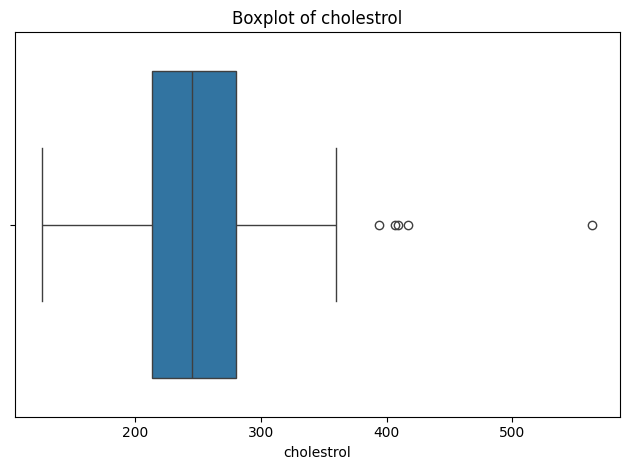

In [30]:
# Boxplot: Let see if there are any outliers

# Define numeric columns
numeric_cols = ["age", "BP", "cholestrol"]

# Loop through columns and plot
for col in numeric_cols:
    plt.figure()  # Creates a new window for each plot
    sns.boxplot(x=df[col].dropna())  # Uses seaborn for clean visualization
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


In [31]:
# 2) Let cap them
# Define numeric columns
numeric_cols = ["age", "BP", "cholestrol"]

for col in numeric_cols:
    # Calculate thresholds
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)

    # Cap the values
    df[col] = np.where(df[col] < lower_limit, lower_limit, df[col])
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])


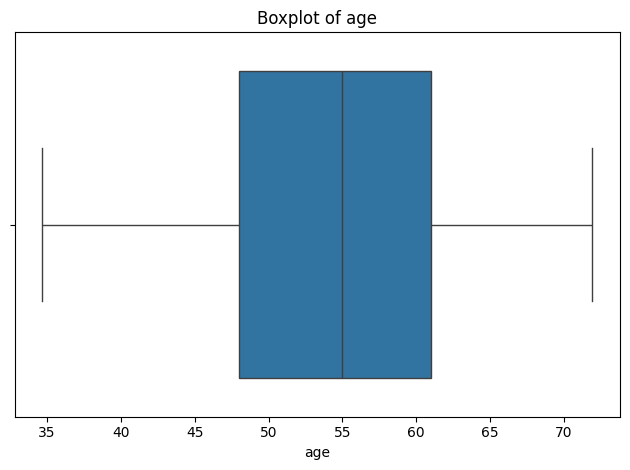

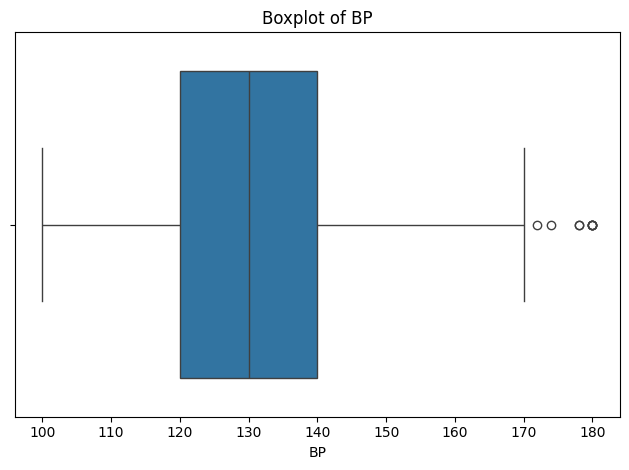

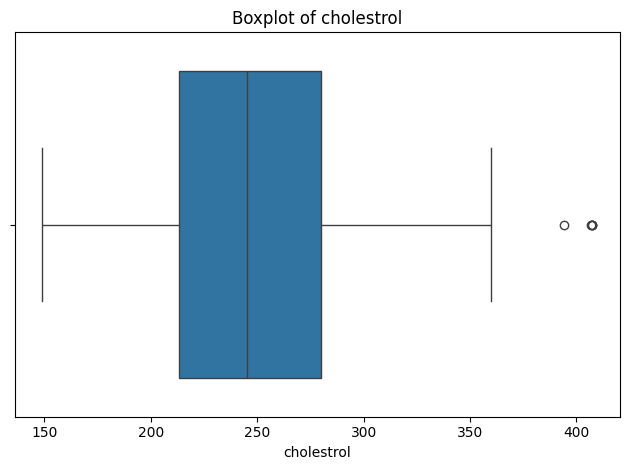

In [32]:
# 3) Loop through columns and plot
for col in numeric_cols:
    plt.figure()  # Creates a new window for each plot
    sns.boxplot(x=df[col].dropna())  # Uses seaborn for clean visualization
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


# missing values

In [33]:

df.isnull().sum()

age              0
sex              0
BP               0
cholestrol       0
heart disease    0
dtype: int64

# 5. Label encoding + Data split: train + test


In [17]:
from sklearn.model_selection import train_test_split

X = df[["age","sex","BP","cholestrol"]]
y = df[["heart disease"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


# 6. Data Preprocessing and Feature Engineering

In [18]:
X_train.isnull().sum()

age           0
sex           0
BP            0
cholestrol    0
dtype: int64

# 7. Modeling + Training

In [19]:
# now lets split the data into train and test

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

# 8. Model Performance + Evaluation

In [20]:
y_predict = model.predict(X_test)
accuracy = accuracy_score(y_predict, y_test)

cm = confusion_matrix(y_predict, y_test)

prfs = precision_recall_fscore_support(y_predict, y_test)
print('Accuracy: ',accuracy)
print('\n')
print('Confusion Matrix:\n ',cm)
print('\n')
print('Precision: ', prfs[0])
print('Recall:    ', prfs[1])
print('Fscore:    ', prfs[2])
print('Support:   ', prfs[3])

Accuracy:  0.6029411764705882


Confusion Matrix:
  [[27 14]
 [13 14]]


Precision:  [0.675 0.5  ]
Recall:     [0.65853659 0.51851852]
Fscore:     [0.66666667 0.50909091]
Support:    [41 27]


# 9. Hyper-parameter Tuning


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

# Define the hyperparameter grid
param_grid = {
    'n_estimators': range(5, 15),
    'max_depth': range(5, 15),
    'max_features': range(5, 13)
}

# Initialize the classifier
model = RandomForestClassifier(random_state=0)

# Perform GridSearchCV
grid_search = GridSearchCV(model, param_grid, cv=3, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search.fit(x_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate on the test set
y_pred = best_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
prfs = precision_recall_fscore_support(y_test, y_pred)

# Print the best parameters and results
print("Best Parameters:", grid_search.best_params_)
print(f"Best Accuracy: {accuracy:.4f}\n")
print("Confusion Matrix:\n", cm)
print("\nPrecision:", prfs[0])
print("Recall:", prfs[1])
print("F-score:", prfs[2])
print("Support:", prfs[3])

Fitting 3 folds for each of 800 candidates, totalling 2400 fits
Best Parameters: {'max_depth': 5, 'max_features': 5, 'n_estimators': 7}
Best Accuracy: 0.7206

Confusion Matrix:
 [[32  8]
 [11 17]]

Precision: [0.74418605 0.68      ]
Recall: [0.8        0.60714286]
F-score: [0.77108434 0.64150943]
Support: [40 28]


In [34]:
# Lets look at best para
print(best_model)
# Best parameters: max_depth=5, max_features=5, n_estimators=7, random_state=0

RandomForestClassifier(max_depth=5, max_features=5, n_estimators=7,
                       random_state=0)


In [33]:
# Now let’s sort the data with the help of feature importance
print(best_model.feature_importances_)
print("########################")

imp_df = pd.DataFrame({
    "Varname": X_train.columns,
    "Imp": best_model.feature_importances_
})

imp_df.sort_values(by="Imp", ascending=False)

# Age is the number one factor in heart disease, next being sex and cholestrol

[0.33026618 0.14945439 0.21977038 0.30050906]
########################


,Varname,Imp
0,age,0.330266
3,cholestrol,0.300509
2,BP,0.219770
1,sex,0.149454


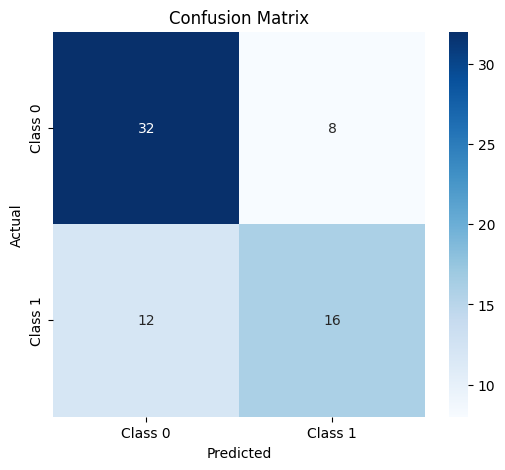

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


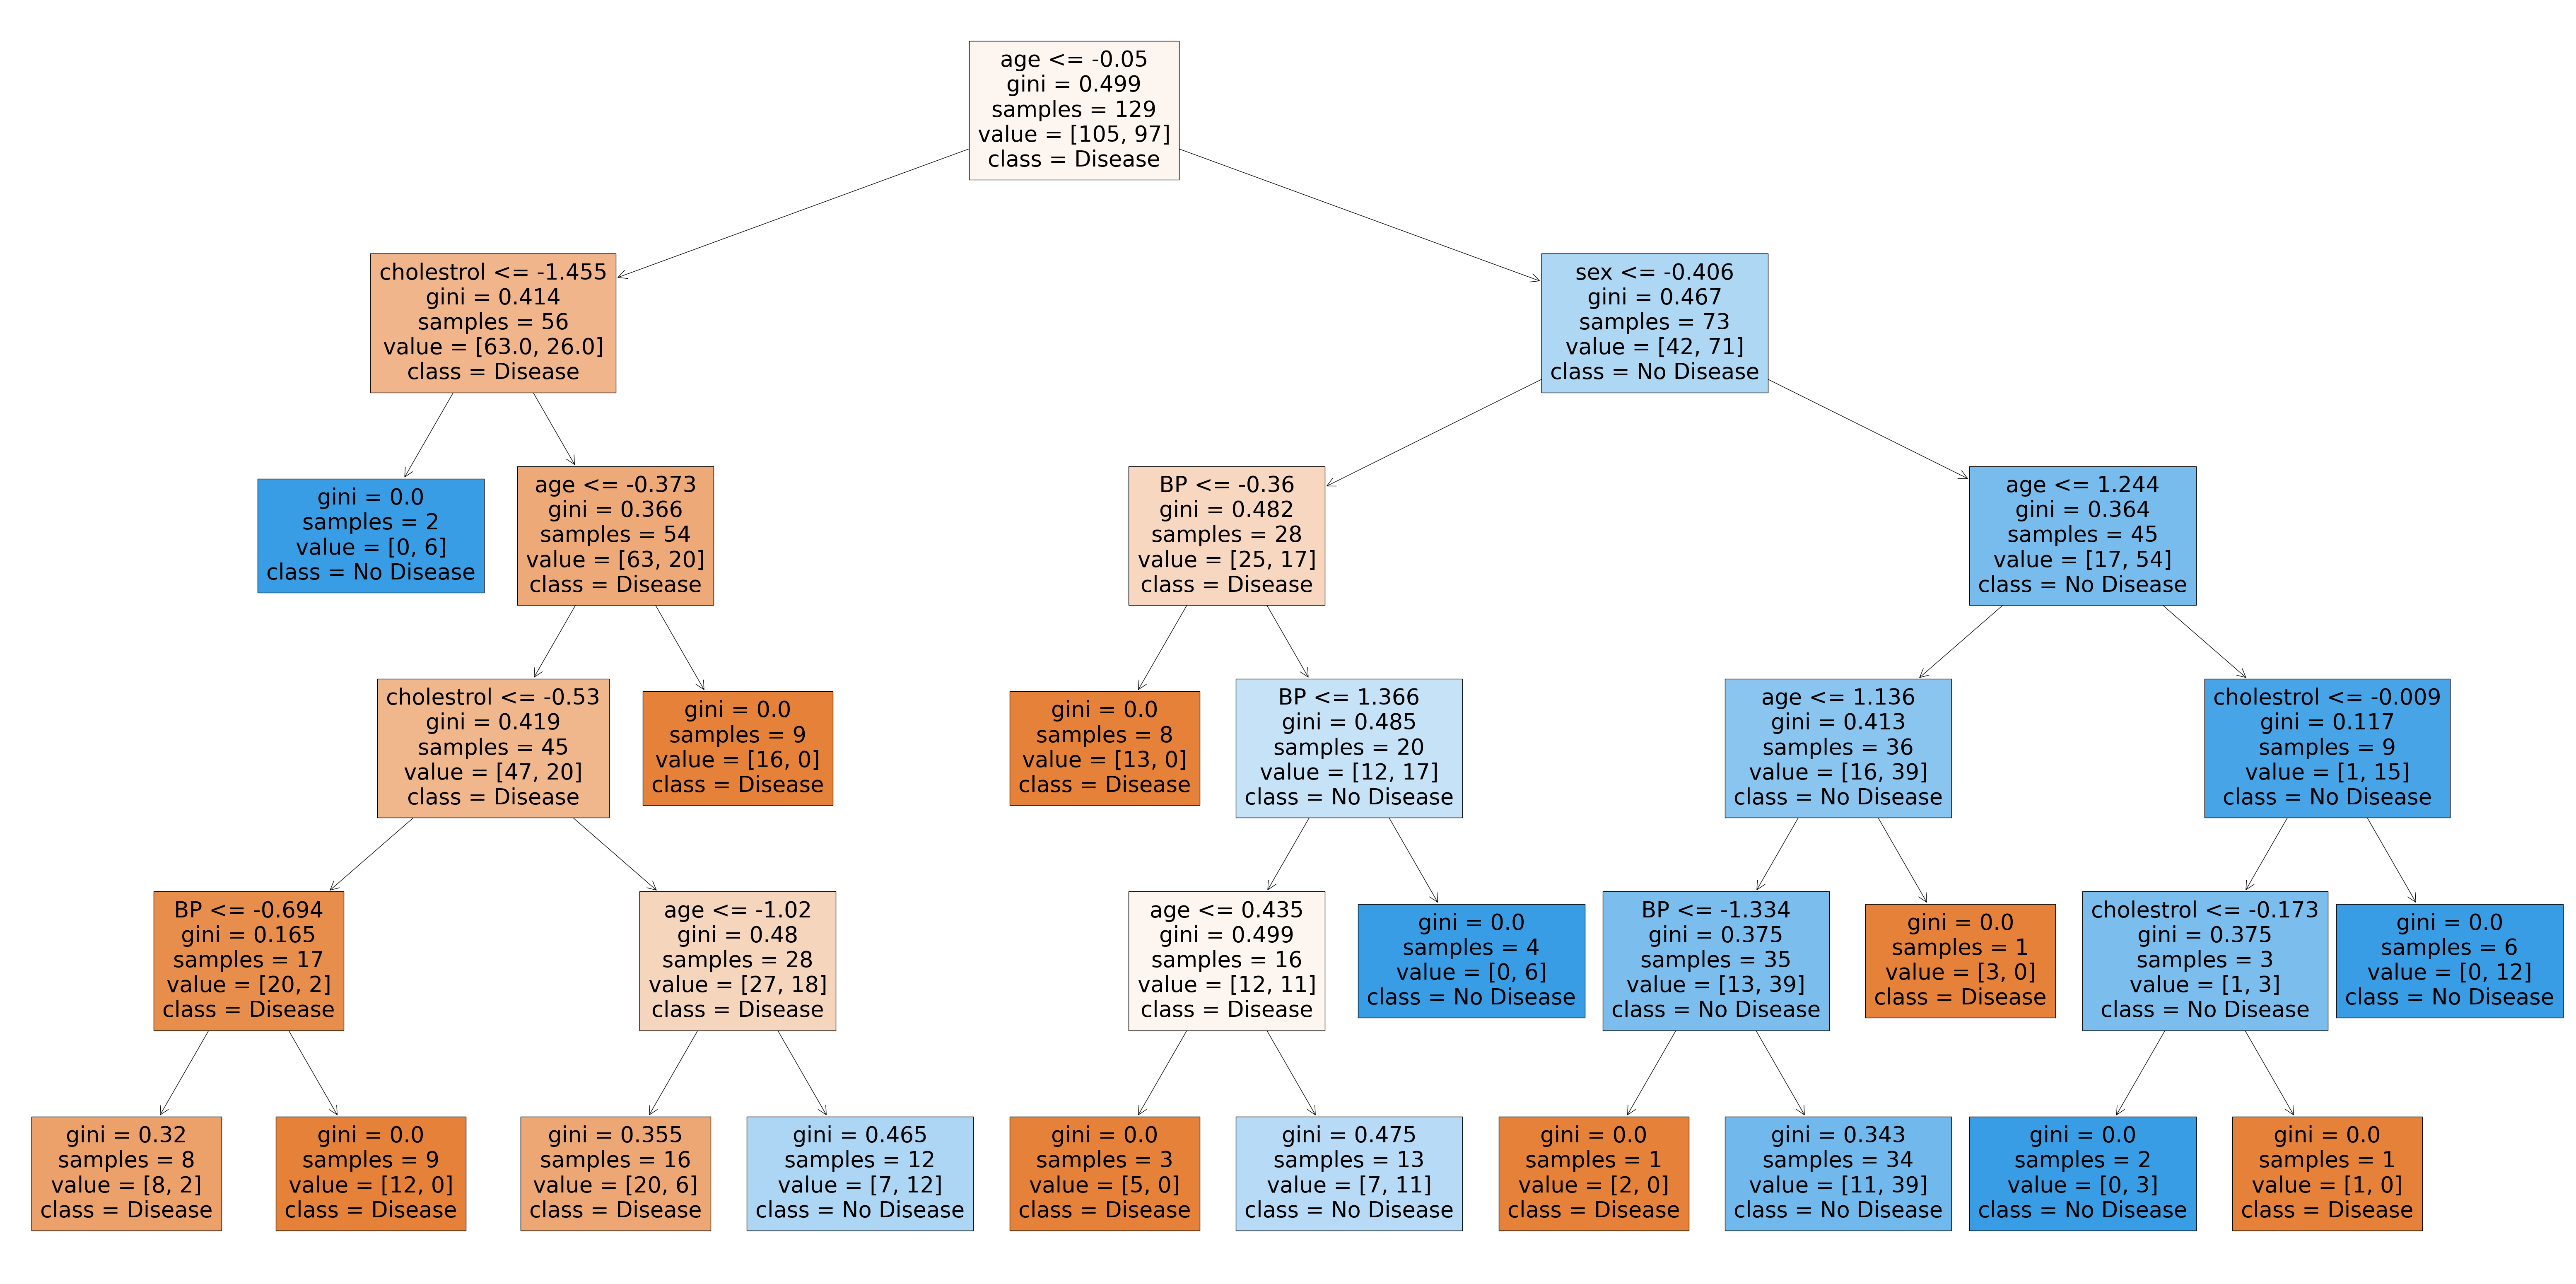

In [32]:
# Lets plot DT for estimator=5
from sklearn.tree import plot_tree

plt.figure(figsize=(80,40))
plot_tree(best_model.estimators_[5], feature_names = X.columns,class_names=['Disease', "No Disease"],filled=True);

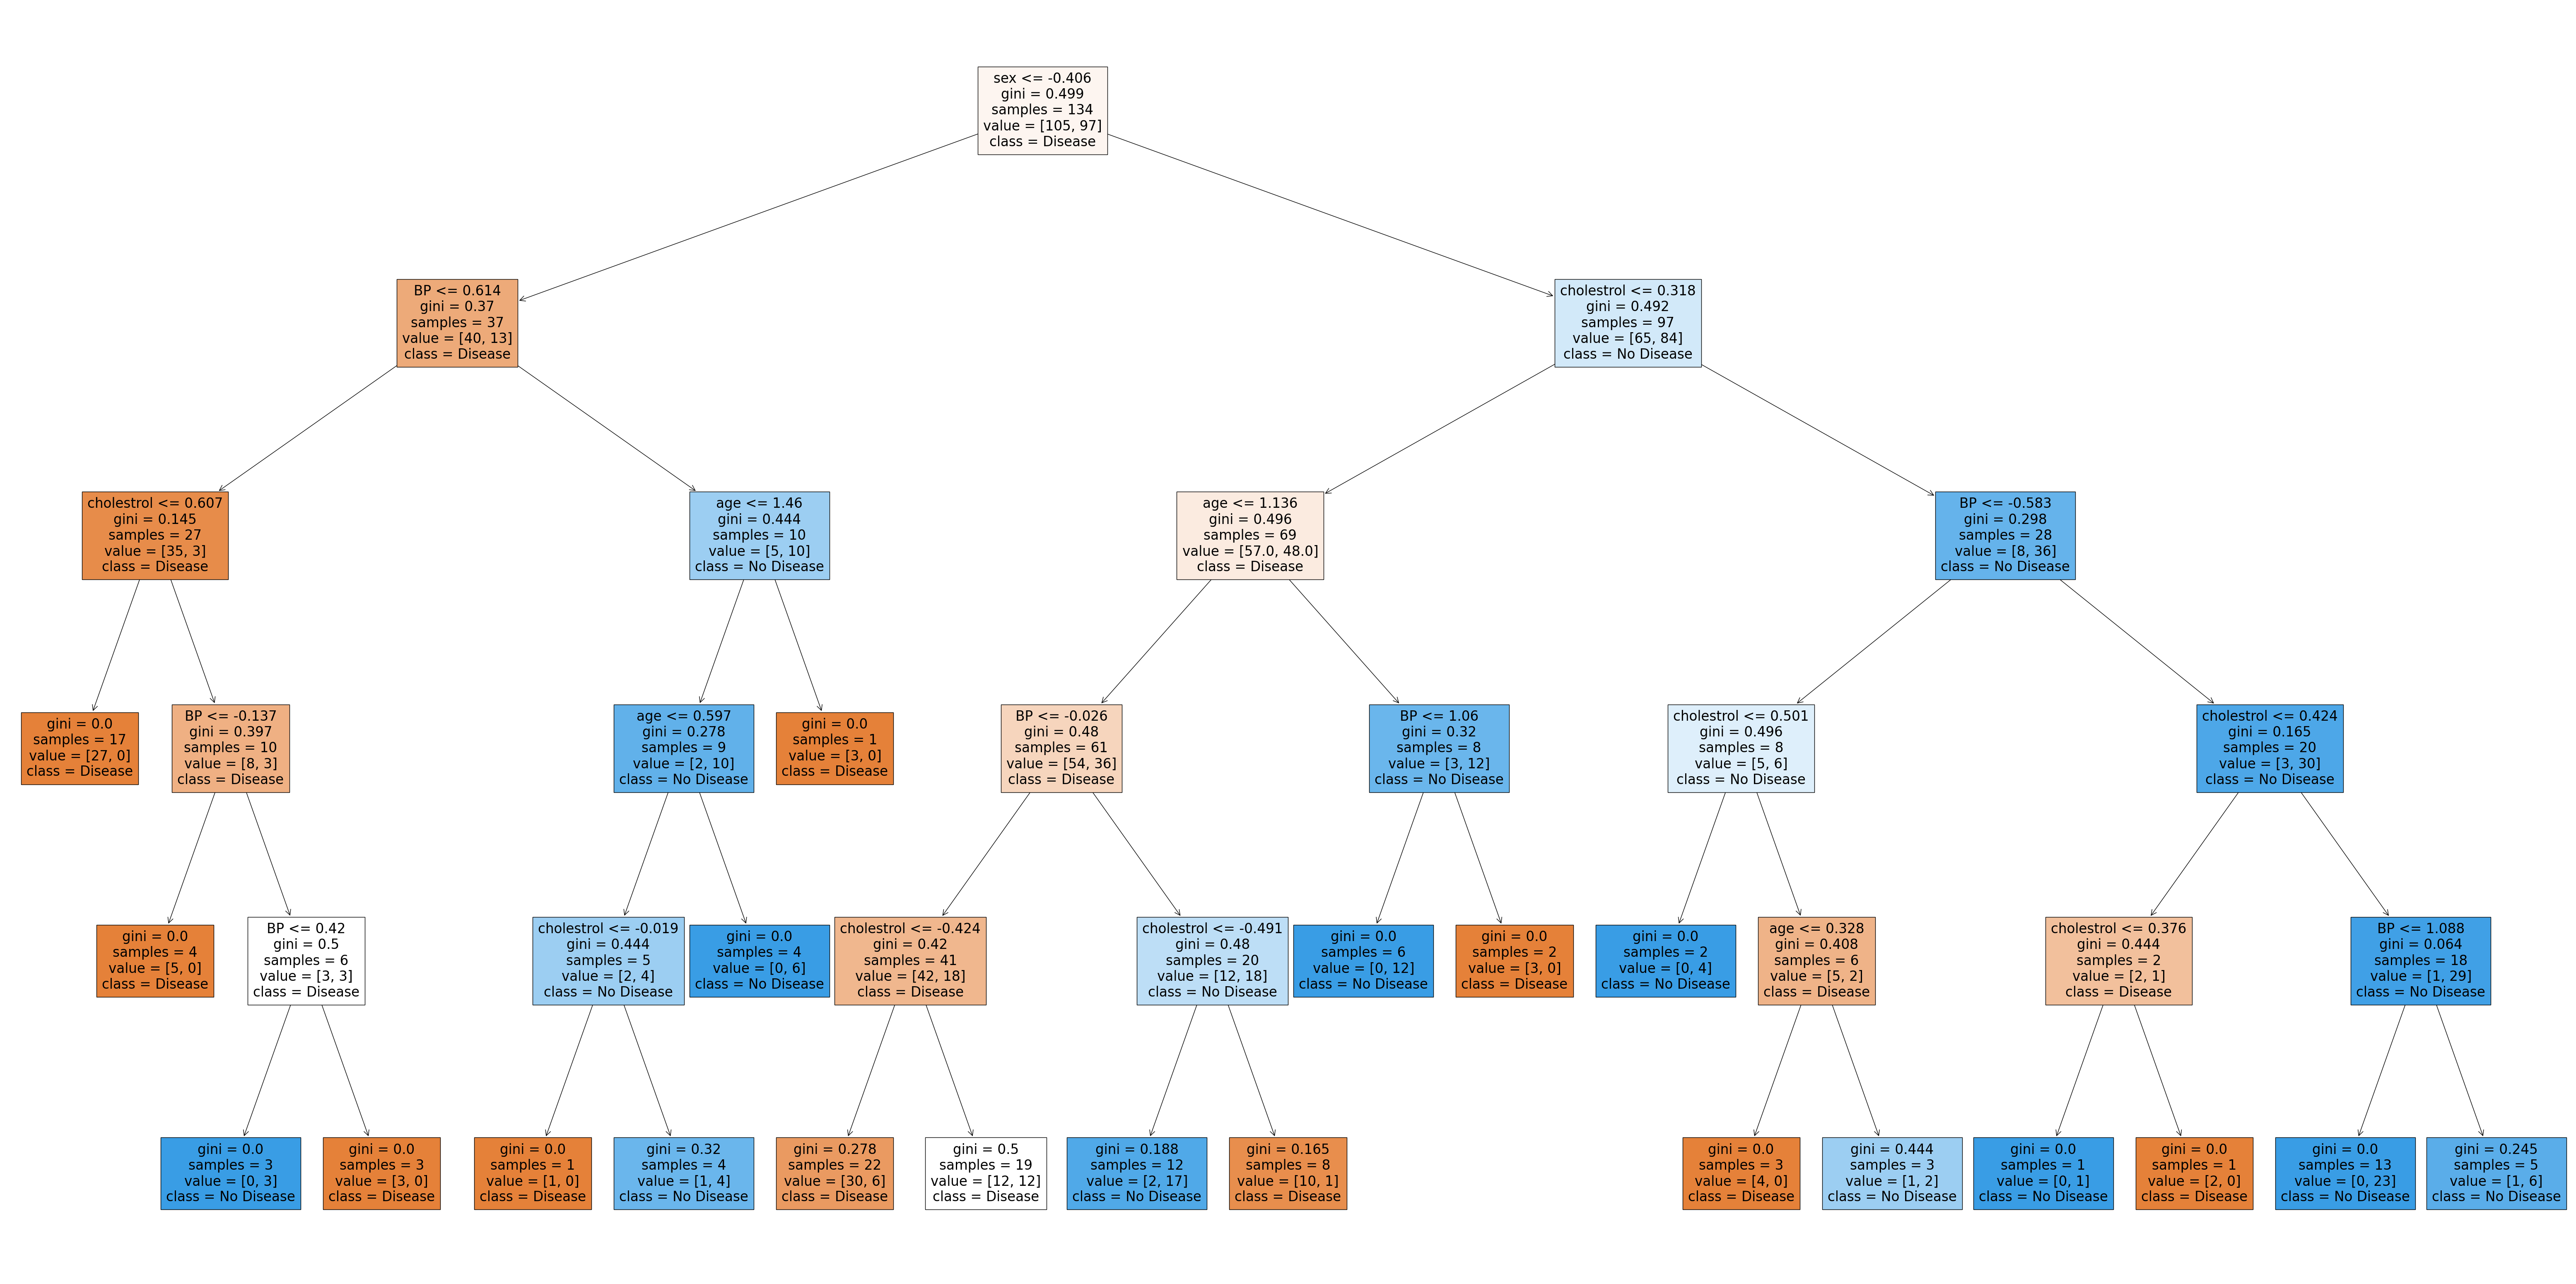

In [37]:
# Lets plot DT for estimator=2
from sklearn.tree import plot_tree

plt.figure(figsize=(80,40))
plot_tree(best_model.estimators_[2], feature_names = X.columns,class_names=['Disease', "No Disease"],filled=True);

# Experimentation

### Let's test if standardization can improve the accuracy
Since RFC uses Decision tree and we know that DT are not influenced by scaling, so the accuracy should not be effected by scaling.
Lets see if this is true.

In [30]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)            # only train

# Fit and transform X
X_train_standardized = scaler.transform(X_train)
X_test_standardized = scaler.transform(X_test)

# Convert back to DataFrame for better readability (optional)
import pandas as pd
X_train_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

# Display standardized values
print(X_train_standardized)
print("**********")
print(X_test_standardized)

          age       sex        BP  cholestrol
0   -1.504969  0.673229 -1.195186   -1.502914
1    2.268127 -1.485378  0.475208   -1.021150
2    0.974494  0.673229 -1.195186   -0.751362
3    1.297902  0.673229 -0.638388   -0.250327
4    0.004269 -1.485378  0.196809    0.000191
..        ...       ...       ...         ...
197  1.297902  0.673229 -0.638388   -0.404491
198  0.758889 -1.485378  0.475208    2.775153
199  0.219875 -1.485378 -0.638388    2.004330
200 -0.426942  0.673229 -1.751984   -0.539385
201 -0.642547 -1.485378 -0.081590    0.366332

[202 rows x 4 columns]
**********
[[ 2.19874881e-01  6.73229092e-01 -1.92949781e-01 -4.04491214e-01]
 [-9.65955179e-01  6.73229092e-01 -6.38388133e-01 -1.90797742e-02]
 [ 1.12072148e-01  6.73229092e-01 -6.38388133e-01 -2.69597210e-01]
 [-3.19138783e-01 -1.48537847e+00  2.52488571e-01 -1.04042009e+00]
 [ 3.27677613e-01 -1.48537847e+00 -1.75198401e+00 -3.83503462e-02]
 [ 1.12072148e-01  6.73229092e-01 -3.59989163e-01 -1.90797742e-02]
 [-1.936179

In [ ]:
# x_train,x_test,y_train,y_test = train_test_split(X_standardized,y,test_size=0.25,random_state=42)

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

# Define the hyperparameter grid
param_grid = {
    'n_estimators': range(5, 15),
    'max_depth': range(5, 15),
    'max_features': range(5, 13)
}

# Initialize the classifier
clf = RandomForestClassifier(random_state=0)

# Perform GridSearchCV
grid_search = GridSearchCV(clf, param_grid, cv=3, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search.fit(X_train_standardized, y_train)

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate on the test set
y_pred = best_model.predict(X_test_standardized)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
prfs = precision_recall_fscore_support(y_test, y_pred)

# Print the best parameters and results
print("Best Parameters:", grid_search.best_params_)
print(f"Best Accuracy: {accuracy:.4f}\n")
print("Confusion Matrix:\n", cm)
print("\nPrecision:", prfs[0])
print("Recall:", prfs[1])
print("F-score:", prfs[2])
print("Support:", prfs[3])

Fitting 3 folds for each of 800 candidates, totalling 2400 fits
Best Parameters: {'max_depth': 5, 'max_features': 5, 'n_estimators': 7}
Best Accuracy: 0.7059

Confusion Matrix:
 [[32  8]
 [12 16]]

Precision: [0.72727273 0.66666667]
Recall: [0.8        0.57142857]
F-score: [0.76190476 0.61538462]
Support: [40 28]


### Not that much difference with standardization
accuracy went from 72.06% to 72.06%.

### Random forest classifier helped in achieving accuracy upto 72 % which is very good cosidering the size and quality of data

In [29]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred)
print(f"ROC-AUC Score: {roc_auc:.4f}") # > 0.8 is good

ROC-AUC Score: 0.6857
